# ANPR Accuracy Test Report

Runs `test_accuracy.py` against every image in `test_images/` and reports the results.

Ground truth for each image comes from its filename (e.g. `LND-113JN.jpeg` → actual plate `LND-113JN`).

In [14]:
import os

import cv2
import pandas as pd
import matplotlib.pyplot as plt

from test_accuracy import run_tests, summarize, TEST_IMAGES_DIR
from anpr_engine_easyocr import run_anpr as easyocr_run_anpr

results = run_tests(run_anpr=easyocr_run_anpr)
summary = summarize(results)

print(f"Tested {len(results)} images (EasyOCR engine).")

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Tested 12 images (EasyOCR engine).


## Test Results

In [15]:
results_df = pd.DataFrame(results)[
    ["filename", "actual_plate", "predicted_plate", "exact_match", "char_accuracy"]
].rename(columns={
    "filename": "Filename",
    "actual_plate": "Actual Plate",
    "predicted_plate": "Predicted Plate",
    "exact_match": "Exact Match",
    "char_accuracy": "Char Accuracy (%)",
})


def highlight_match(row):
    color = "background-color: #d4edda" if row["Exact Match"] == "YES" else "background-color: #f8d7da"
    return [color] * len(row)


results_df.style.apply(highlight_match, axis=1).hide(axis="index")

Filename,Actual Plate,Predicted Plate,Exact Match,Char Accuracy (%)
BDG-889HS.jpeg,BDG-889HS,IBDG-889HS,NO,94.700000
FKJ-981HZ.jpeg,FKJ-981HZ,J-981H2,NO,75.000000
FST-177DM.jpeg,FST-177DM,(none),NO,0.000000
GGE-586EM.jpeg,GGE-586EM,GGE-586EM,YES,100.000000
JJJ-905HT.jpeg,JJJ-905HT,TJJ905HT,NO,82.400000
KJA-493GY.jpeg,KJA-493GY,KJA4936Y4,NO,77.800000
KSF-17GU.jpeg,KSF-17GU,KSE-17GU,NO,87.500000
KTU-116AW.jpeg,KTU-116AW,KTUII6AN,NO,58.800000
KUJ-463TU.jpeg,KUJ-463TU,KULA63TU,NO,70.600000
LND-113JN.jpeg,LND-113JN,LND-113JN,YES,100.000000


## Visual Results

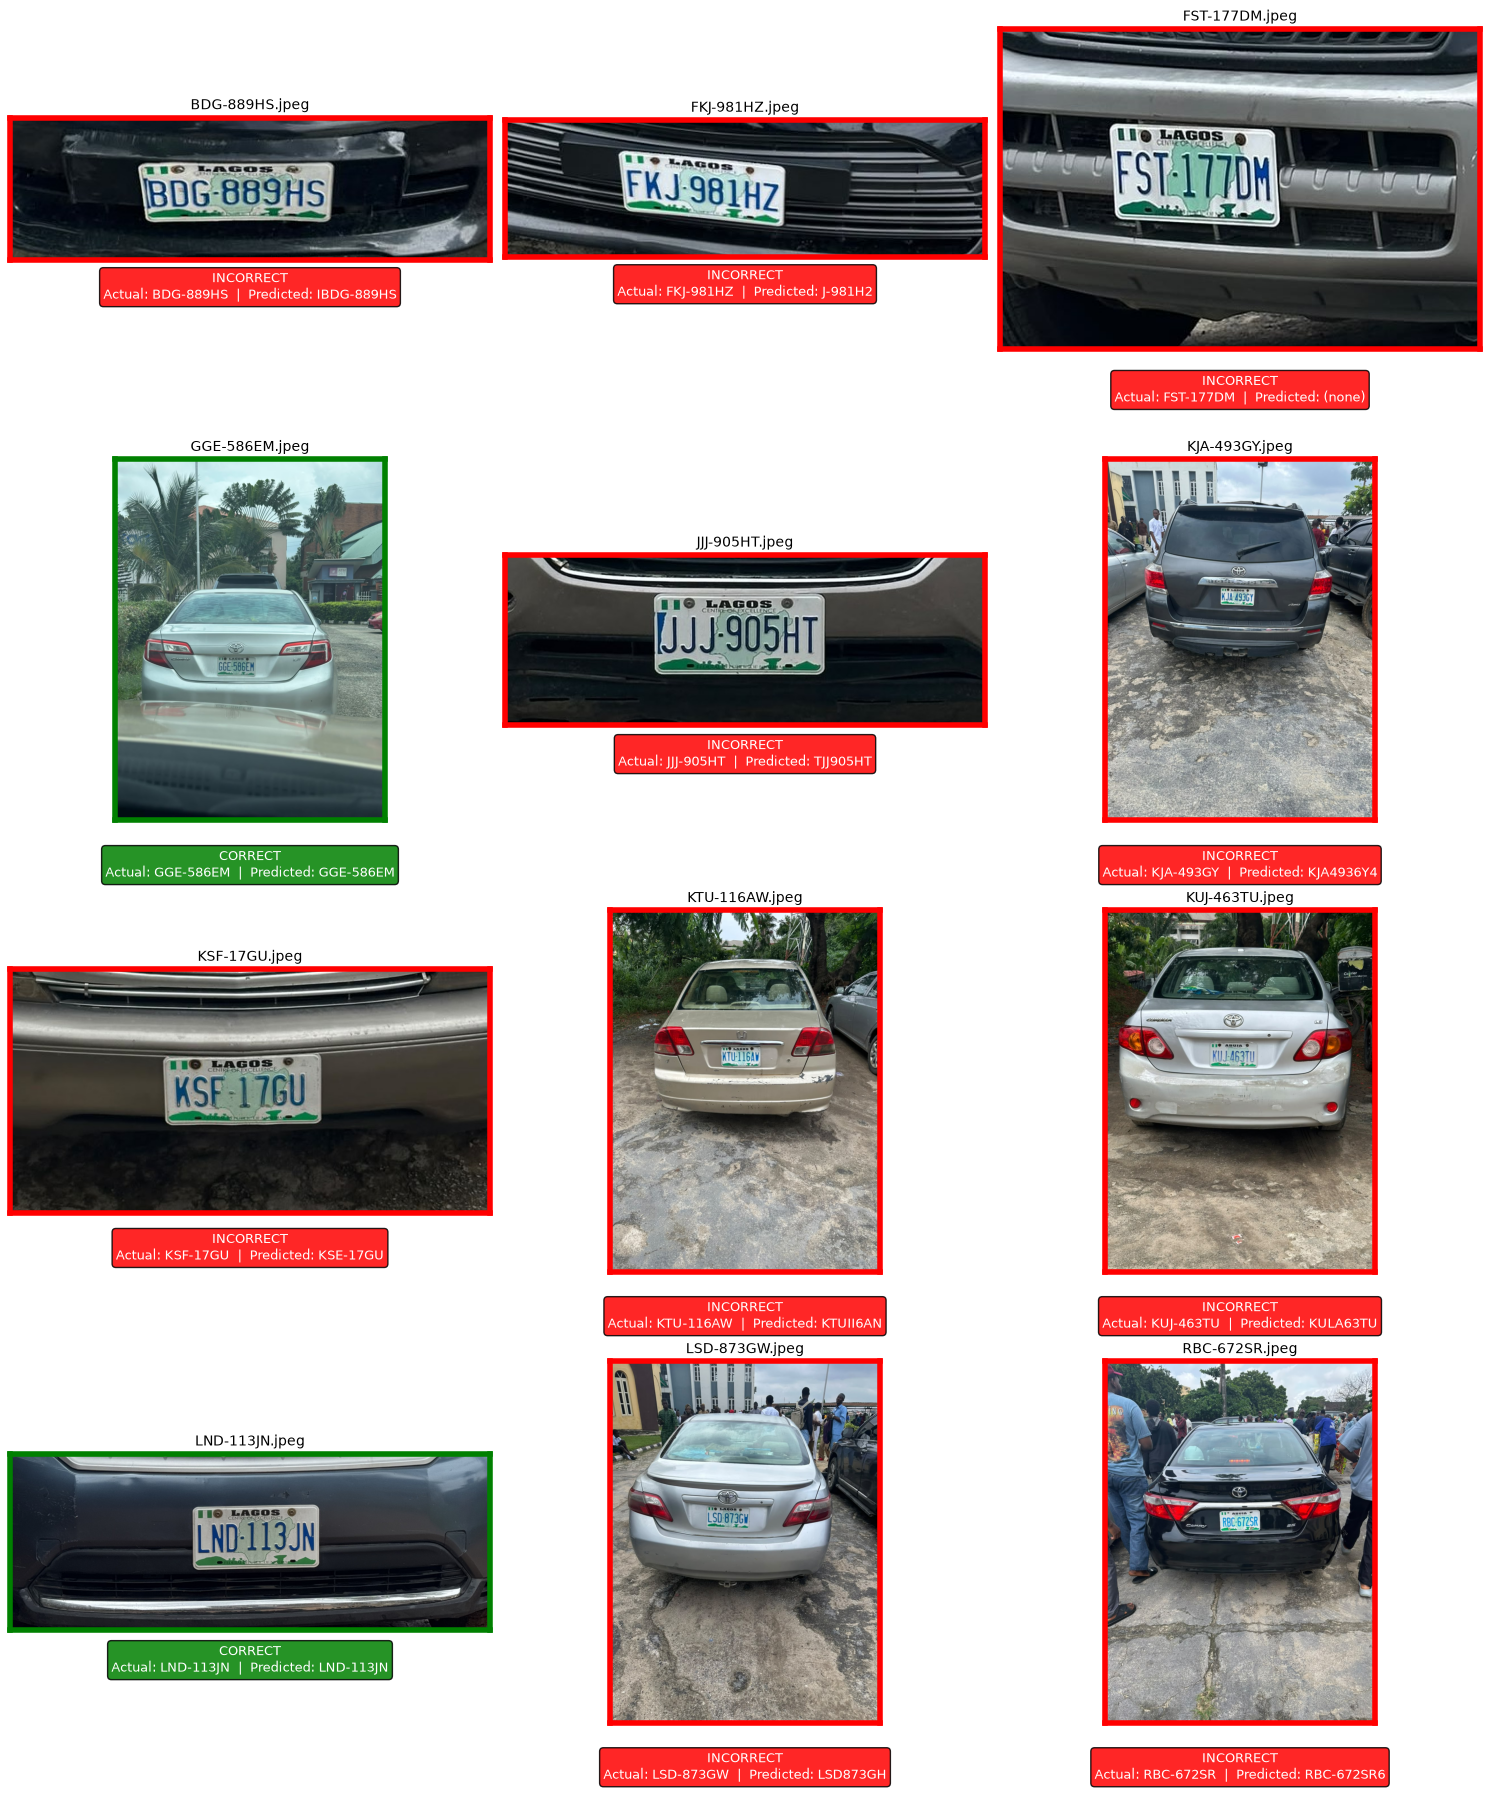

In [16]:
n = len(results)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for ax, result in zip(axes, results):
    img_path = os.path.join(TEST_IMAGES_DIR, result["filename"])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    is_correct = result["exact_match"] == "YES"
    color = "green" if is_correct else "red"
    label = "CORRECT" if is_correct else "INCORRECT"

    ax.imshow(img)
    ax.set_title(result["filename"], fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color(color)
        spine.set_linewidth(4)

    ax.text(
        0.5, -0.08,
        f"{label}\nActual: {result['actual_plate']}  |  Predicted: {result['predicted_plate']}",
        transform=ax.transAxes, ha="center", va="top", fontsize=9,
        color="white", bbox=dict(facecolor=color, alpha=0.85, boxstyle="round,pad=0.3"),
    )

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Failed Reads — Pipeline Stage Comparison

For each failed read (Tesseract engine, since EasyOCR has no separate threshold stage), shows the original image, the detected/cropped plate region, the thresholded image actually fed to OCR, and the incorrect text that came out.

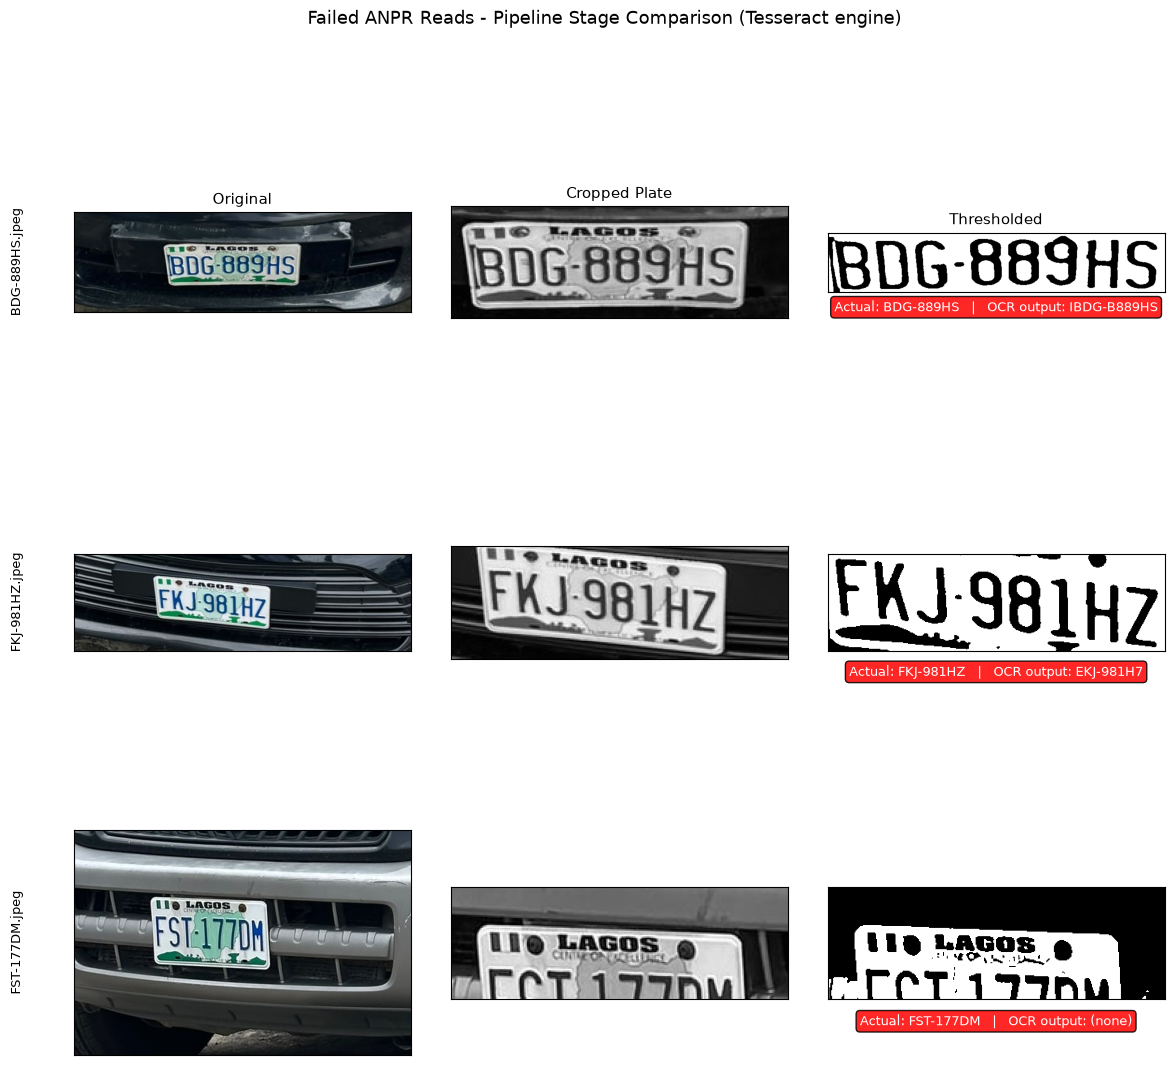

In [17]:
import anpr_engine

# Uses the Tesseract engine specifically (not whichever engine populated
# `results` above) since the threshold stage below only exists in that
# pipeline - EasyOCR does detection+recognition in one pass with no
# separate thresholding step.
tesseract_results = run_tests(run_anpr=anpr_engine.run_anpr)
failed = [r for r in tesseract_results if r["exact_match"] == "NO"][:3]

if not failed:
    print("No failed reads to show - the Tesseract engine got every test image exactly right.")
else:
    col_titles = ["Original", "Cropped Plate", "Thresholded"]
    fig, axes = plt.subplots(len(failed), 3, figsize=(12, 4 * len(failed)))
    axes = axes.reshape(len(failed), 3)

    for row, result in enumerate(failed):
        path = os.path.join(TEST_IMAGES_DIR, result["filename"])
        original = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        cropped = anpr_engine.detect_plate(path)

        thresh_img = None
        if cropped is not None:
            band = anpr_engine._isolate_number_line(cropped)
            if band.size == 0:
                band = cropped

            min_height = 120
            if band.shape[0] < min_height:
                scale = min_height / band.shape[0]
                band = cv2.resize(band, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

            blurred = cv2.GaussianBlur(band, (3, 3), 0)
            _, thresh_img = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        images = [original, cropped, thresh_img]
        cmaps = [None, "gray", "gray"]

        for col, (img, cmap) in enumerate(zip(images, cmaps)):
            ax = axes[row, col]
            if img is None:
                ax.text(0.5, 0.5, "N/A", ha="center", va="center", transform=ax.transAxes)
            else:
                ax.imshow(img, cmap=cmap)
            ax.set_xticks([])
            ax.set_yticks([])
            if row == 0:
                ax.set_title(col_titles[col], fontsize=11)

        axes[row, 0].text(
            -0.15, 0.5, result["filename"],
            transform=axes[row, 0].transAxes, ha="right", va="center", fontsize=9, rotation=90,
        )
        axes[row, 2].text(
            0.5, -0.14,
            f"Actual: {result['actual_plate']}   |   OCR output: {result['predicted_plate']}",
            transform=axes[row, 2].transAxes, ha="center", va="top", fontsize=9,
            color="white", bbox=dict(facecolor="red", alpha=0.85, boxstyle="round,pad=0.3"),
        )

    plt.suptitle("Failed ANPR Reads - Pipeline Stage Comparison (Tesseract engine)", fontsize=13)
    plt.tight_layout()
    plt.show()

## Summary Statistics

In [18]:
summary_df = pd.DataFrame([{
    "Total Images Tested": summary["total_images"],
    "Exact Match Count": summary["exact_match_count"],
    "Exact Match Accuracy (%)": summary["exact_match_accuracy_pct"],
    "Avg Character Accuracy (%)": summary["avg_char_accuracy_pct"],
    "Avg Processing Time (s)": summary["avg_processing_time_sec"],
}])

summary_df.style.hide(axis="index")

Total Images Tested,Exact Match Count,Exact Match Accuracy (%),Avg Character Accuracy (%),Avg Processing Time (s)
12,2,16.700000,77.000000,12.903000
